In [102]:
from sklearn.datasets import make_regression

# generating data
x, y = make_regression(n_samples=100, n_features=10, noise=1, random_state=42)

Text(0.5, 0, 'Feature 1')

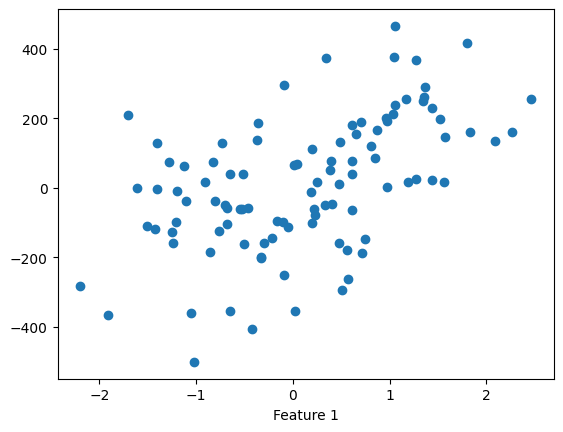

In [103]:
import matplotlib.pyplot as plt

plt.scatter(x[:, 5], y)
plt.xlabel("Feature 1")

# Univariate regression

```math
\hat{y} = w*x+b
```

In [104]:
b = -25.0
w = 100.0

def predict(w: float, x: float, b: float) -> float:
    """ write a function that predicts y given x, w and b in the case of univariate linear regression"""
    ...
    return w * x + b

Text(0.5, 0, 'Feature 1')

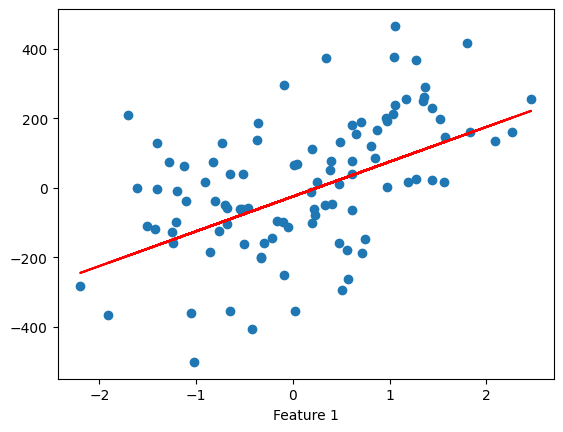

In [105]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(x[:, 5], y)
# add a line representing the model
plt.plot(x[:, 5], predict(w, x[:, 5], b), color='red')
plt.xlabel("Feature 1")

## Loss: squared error

```math
L_{w,b}(x) = \frac{1}{2}(\hat{y}-y)^2 = \frac{1}{2}(w*x+b-y)^2
```

In [106]:
def error(y_true: float, y_pred: float) -> float:
    """ write a function that computes the squared error between y_true and y_pred """
    ...
    return 1/2 * (y_true - y_pred) ** 2

In [107]:
error(y, predict(w, x[:, 5], b))

array([6.96854549e+04, 3.43705916e+04, 6.04529856e+03, 1.05301523e+04,
       2.67023099e+03, 2.42678296e+02, 2.71782767e+04, 3.92459707e+03,
       2.94593048e+03, 2.03516007e+03, 2.36711246e+04, 1.60864322e+03,
       1.11263642e+04, 9.90731096e+03, 2.86874357e+03, 1.95389090e+04,
       3.07531572e+04, 6.50845467e+03, 2.14145617e+00, 6.59463533e+02,
       2.08159626e+03, 1.21911540e+03, 4.69727216e+03, 3.43647263e+03,
       3.48225645e+04, 1.47704066e+03, 4.43370624e+04, 3.79105043e+03,
       2.23704161e+04, 1.91247755e+03, 2.35387709e+02, 5.89655827e+02,
       1.43074176e+02, 1.64549836e+01, 7.42312199e+04, 2.35904159e+03,
       9.07875015e+03, 8.32595406e+03, 7.29718994e+01, 1.34640906e+04,
       5.00171968e+03, 1.74458332e+04, 1.39232555e+02, 4.83388675e+03,
       6.62510389e+04, 8.27283595e+02, 1.02765844e+04, 5.51769484e+04,
       8.80240753e+03, 1.12760875e+03, 5.02813563e+00, 8.32908648e+03,
       9.85556838e+01, 2.63986095e+04, 2.19990998e+03, 1.71346192e+02,
      

## Cost function

```math
J_{w,b} = \frac{1}{2m}\sum{L_{w,b}(x)}

```

In [108]:
def loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """ write a function that computes the mean squared error between y_true and y_pred """
    ...
    return sum(error(y_true, y_pred)) / len(y_true)

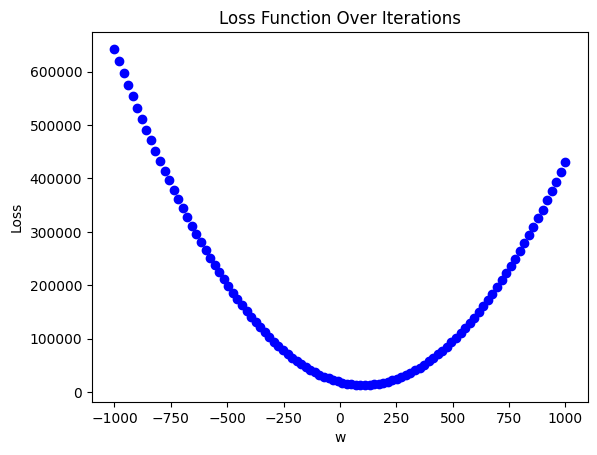

In [109]:
# plot loss function for different values of w
import matplotlib.pyplot as plt

losses = np.linspace(-1000, 1000, 100)
for w in losses:
    plt.scatter(w, loss(y, predict(w, x[:, 5], b)), color='blue')
plt.xlabel("w")
plt.ylabel("Loss")
plt.title("Loss Function Over Iterations")
plt.show()

In [110]:
loss(y, predict(w, x[:, 5], b))

np.float64(430367.0750552666)

## Gradient Descent Step

```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{(\hat{y}-y)x}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```

Iteration 1/1000, Loss: 346787.7553661841
Iteration 2/1000, Loss: 323494.1237044031
Iteration 3/1000, Loss: 324959.8467950869
Iteration 4/1000, Loss: 336998.15788647183
Iteration 5/1000, Loss: 353968.9347560083
Iteration 6/1000, Loss: 373656.5751319873
Iteration 7/1000, Loss: 395219.2560365468
Iteration 8/1000, Loss: 418367.9796071957
Iteration 9/1000, Loss: 443038.0332200934
Iteration 10/1000, Loss: 469257.6218421429
Iteration 11/1000, Loss: 497095.4587772795
Iteration 12/1000, Loss: 526639.9828405913
Iteration 13/1000, Loss: 557991.2510238617
Iteration 14/1000, Loss: 591257.9194794362
Iteration 15/1000, Loss: 626556.2757283191
Iteration 16/1000, Loss: 664010.1068916164
Iteration 17/1000, Loss: 703750.9182793763
Iteration 18/1000, Loss: 745918.3088303882
Iteration 19/1000, Loss: 790660.4269349021
Iteration 20/1000, Loss: 838134.4770960329
Iteration 21/1000, Loss: 888507.2667393424
Iteration 22/1000, Loss: 941955.7900986575
Iteration 23/1000, Loss: 998667.8492304287
Iteration 24/1000, 

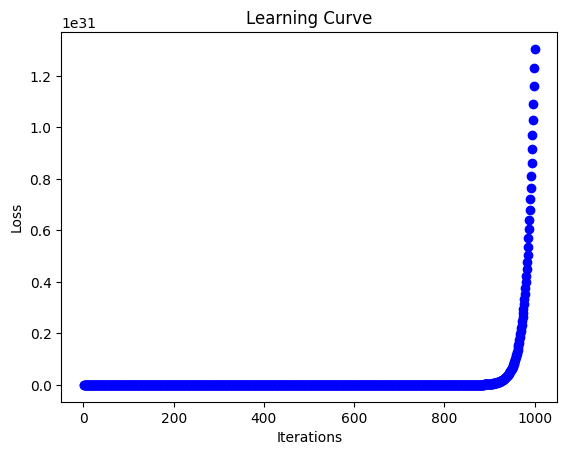

(np.float64(3770898268122767.0), np.float64(3214877057811507.0))

In [111]:
def gradient(y_true: float, y_pred: float, x: float) -> tuple[float, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    dw = ((y_pred - y_true) * x).mean()
    db = (y_pred - y_true).mean()
    return dw, db

def update_parameters(w: float, b: float, dw: float, db: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that updates the parameters w and b using the gradients dw and db and the learning rate """
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b



def gradient_descent(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float, n_iterations: int, eta: float) -> tuple[float, float]:
    """ write a function that performs gradient descent to optimize w and b """
    y_pred = predict(w, x, b)
    current_loss = loss(y, y_pred)
    for i in range(n_iterations):
        
        dw, db = gradient(y, y_pred, x)
        w, b = update_parameters(w, b, dw, db, learning_rate)
        y_pred = predict(w, x, b)
        new_loss = loss(y, y_pred)
        
        print(f"Iteration {i+1}/{n_iterations}, Loss: {new_loss}")
        plt.scatter(i+1, current_loss, color='blue')
        if abs(current_loss - new_loss) < eta:
            break
        current_loss = new_loss
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("Learning Curve")
    plt.show()

    return w, b

gradient_descent(x[:, 5], y, w, b, learning_rate=1.8, n_iterations=1000, eta=1e-3)

# Multivariate regression

```math
\hat{y} = w.x^T+b
```

In [112]:
def predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression"""
    return np.dot(w, x.T) + b

w = np.random.randn(x.shape[1])
b = 0.0

In [113]:
predict(w, x, b)

array([ 1.96663266,  2.5887053 , -2.1237531 , -1.15658366, -2.55918851,
       -1.7250328 ,  4.71477426,  2.97805642,  0.37154498, -0.41980054,
        0.79756743,  2.05955937,  2.0642697 , -1.47974912, -0.53933105,
        2.39269378, -2.49688056, -1.51046465, -1.75647976, -3.41155725,
       -2.74150899,  1.20305938,  2.82309869, -1.53589212,  0.54321811,
       -2.4934927 ,  0.06558637,  1.93611712, -2.63832461, -3.40237683,
        1.49219563,  0.01003922, -1.39862803, -1.30649075,  0.25603024,
        1.82408655, -1.47650539,  0.23135563,  0.4562389 , -3.06975967,
       -1.93194524,  5.32104374,  0.38272766, -1.7450332 ,  1.02880141,
       -0.05039138,  0.64280271,  2.70124991,  1.32696512,  3.19823938,
        0.23901534, -3.72027356, -0.9112215 , -0.08565675, -0.05264926,
        2.14891569,  1.51565326,  3.71271011, -0.6168276 , -0.03754765,
        1.71981903, -0.31569673,  0.27442477,  1.61450231, -0.6431508 ,
       -0.59308652, -1.81628787, -2.64357088, -1.25954844,  2.13

In [114]:
loss(y, predict(w, x, b))

np.float64(18353.02112424152)

## Gradient Descent Step


```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{x^T.(\hat{y}-y)}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```

In [115]:
def gradient(y_true: np.ndarray, y_pred: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    ...
    dw = np.dot(x.T, (y_pred - y_true)) / len(y_true)
    db = np.sum(y_pred - y_true) / len(y_true)
    return dw, db

gradient(y, predict(w, x, b), x)

(array([ -29.51314576,  -56.34350645,   -9.06738026,  -71.18125567,
         -80.62277505, -103.50913874, -104.99422271,   35.63353956,
         -18.14847426,  -68.52644854]),
 np.float64(-11.199329970615638))

Iteration 1/1000, Loss: 14249.706832989916
Iteration 2/1000, Loss: 11126.845828622389
Iteration 3/1000, Loss: 8738.66506661654
Iteration 4/1000, Loss: 6903.151695111778
Iteration 5/1000, Loss: 5485.101209487085
Iteration 6/1000, Loss: 4383.7524961596955
Iteration 7/1000, Loss: 3523.7527473992404
Iteration 8/1000, Loss: 2848.5429423927867
Iteration 9/1000, Loss: 2315.505443596464
Iteration 10/1000, Loss: 1892.396378385367
Iteration 11/1000, Loss: 1554.7163615639072
Iteration 12/1000, Loss: 1283.7677855017841
Iteration 13/1000, Loss: 1065.2154500381466
Iteration 14/1000, Loss: 888.0169870959458
Iteration 15/1000, Loss: 743.6255876612718
Iteration 16/1000, Loss: 625.3937334718452
Iteration 17/1000, Loss: 528.1256936388169
Iteration 18/1000, Loss: 447.7404321285621
Iteration 19/1000, Loss: 381.0167051331728
Iteration 20/1000, Loss: 325.39953450656617
Iteration 21/1000, Loss: 278.8526678217907
Iteration 22/1000, Loss: 239.74561575041088
Iteration 23/1000, Loss: 206.76678404678205
Iteration 

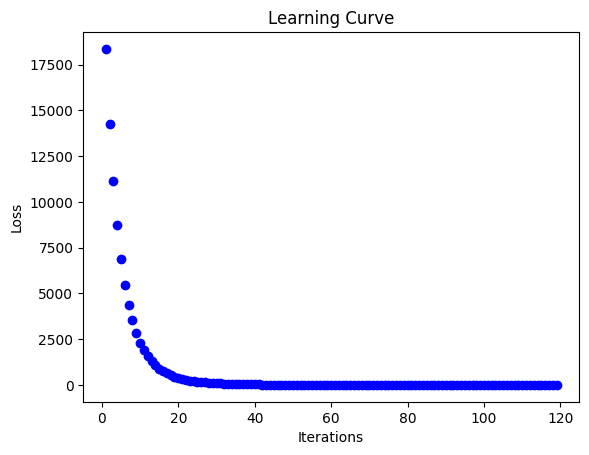

(array([16.92938113, 54.29705894,  5.00404239, 63.57530237, 93.53057194,
        70.65792547, 86.85713402, 10.23045337,  3.23924013, 70.78937453]),
 np.float64(0.11345025370472153))

In [116]:
gradient_descent(x, y, w, b, learning_rate=0.1, n_iterations=1000, eta=1e-3)

In [97]:
def predict(w: np.ndarray, x: np.ndarray, b: float, l: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression with L2 regularization"""
    return np.dot(w, x.T) + b

def gradient(y_true: np.ndarray, y_pred: np.ndarray, x: np.ndarray, w: np.ndarray, l: float) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b with L2 regularization """
    ...
    dw = (np.dot(x.T, (y_pred - y_true)) + l * w) / len(y_true)
    db = np.sum(y_pred - y_true) / len(y_true)
    return dw, db

